# Towsey Walkthrough

In [45]:
import sys
from pathlib import Path
import numpy as np
import torch
import torchaudio as ta
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))
import utilities.configs as configs
import utilities.utils as utils


def show_spec(S, title, sr=64_000, hop=512, cmap="magma",
              vmin=None, vmax=None, ax=None, ylabel="Mel bin", mel_start=0, mel_end=None,
              start_sec=None, end_sec=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(13, 4))
    n_bins, n_frames = S.shape
    mel_slice_end = n_bins if mel_end is None else min(n_bins, max(mel_start, mel_end) - mel_start)
    start_idx = 0 if start_sec is None else max(0, int(np.floor(start_sec * sr / hop)))
    end_idx = n_frames if end_sec is None else min(n_frames, int(np.ceil(end_sec * sr / hop)))
    if end_idx <= start_idx:
        end_idx = min(n_frames, start_idx + 1)
    S_plot = S[:mel_slice_end, start_idx:end_idx]
    plot_start_sec = start_idx * hop / sr
    plot_end_sec   = end_idx   * hop / sr
    plot_mel_end   = mel_start + S_plot.shape[0]
    tick_positions = np.linspace(mel_start, plot_mel_end - 1, min(5, S_plot.shape[0]))
    tick_labels    = [str(int(round(p))) for p in tick_positions]
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)
    im = ax.imshow(S_plot, origin="lower", aspect="auto", cmap=cmap,
                   extent=[plot_start_sec, plot_end_sec, mel_start, plot_mel_end],
                   interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    plt.colorbar(im, ax=ax, shrink=0.9).set_label("dB")
    if standalone:
        plt.tight_layout()
        plt.show()

In [46]:
# Parameters to adjust
AUDIO_FILE = Path(ROOT / "data/mixedDataset/6230.220915010000.wav") # 6230.220915010000.wav at 125+5 start sec is narwhal call
START_SEC  = 125 + 5
END_SEC    = START_SEC + 5
MEL_START  = 11
MEL_END    = None
TOWSEY_N   = 0.0    # try 0.5, 1.0, 2.0
SMOOTH_WIN = 5
NEIGH_THR  = 2.0





cfg = configs.get_specgram_config()
SR  = cfg["sample_rate"]
HOP = cfg["hop_length"]


specgram_config = dict(**cfg) # unpack config
specgram_config["use_towsey"] = False
pipeline = utils.PipelineSpecgram(specgram_config=specgram_config)
pipeline.eval()

/Users/johan/miniconda3/envs/narwhal_env/lib/python3.12/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


PipelineSpecgram(
  (to_db): AmplitudeToDB()
  (resample): Identity()
  (spec): Spectrogram()
  (mel_scale): MelScale()
)

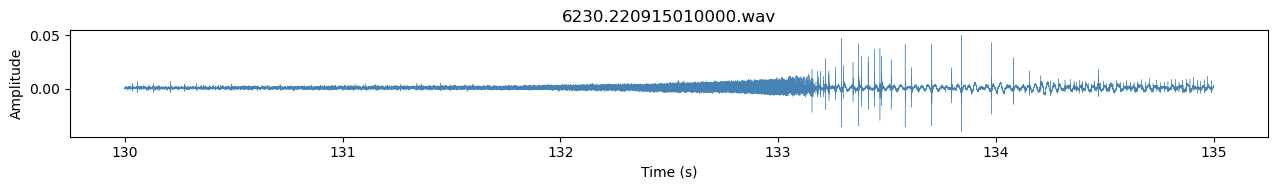

In [47]:
waveform, sr = ta.load(str(AUDIO_FILE))
waveform_plot = waveform[:, int(START_SEC * sr):int(END_SEC * sr)]
time_axis = np.linspace(START_SEC, END_SEC, waveform_plot.shape[-1])

fig, ax = plt.subplots(figsize=(13, 2))
ax.plot(time_axis, waveform_plot[0].numpy(), linewidth=0.3, color="steelblue")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(AUDIO_FILE.name)
plt.tight_layout()
plt.show()

## Preprocessing

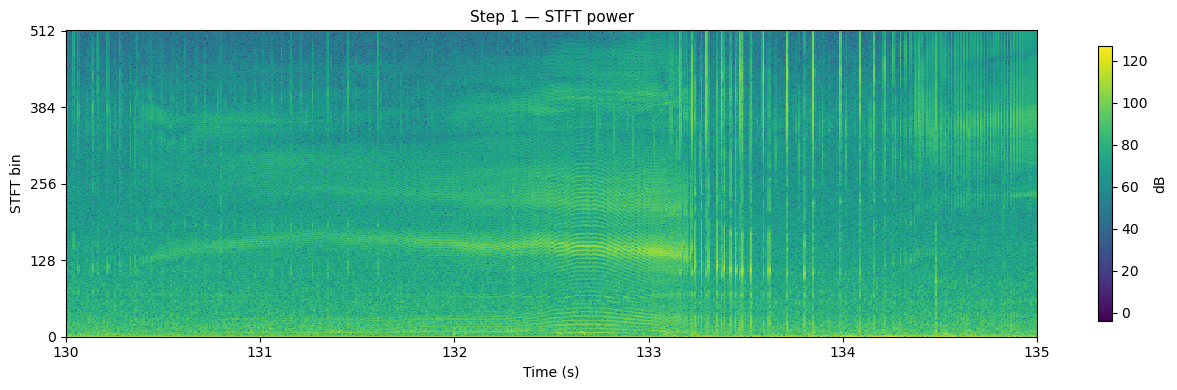

In [48]:
with torch.no_grad():
    power_spec = pipeline.spec(waveform)   # (1, 513, T)

power_db_np = pipeline.to_db(power_spec / (1e-6 ** 2)).squeeze(0).numpy()

show_spec(power_db_np, "Step 1 — STFT power",
          sr=SR, hop=HOP, cmap="viridis", ylabel="STFT bin",
          start_sec=START_SEC, end_sec=END_SEC)

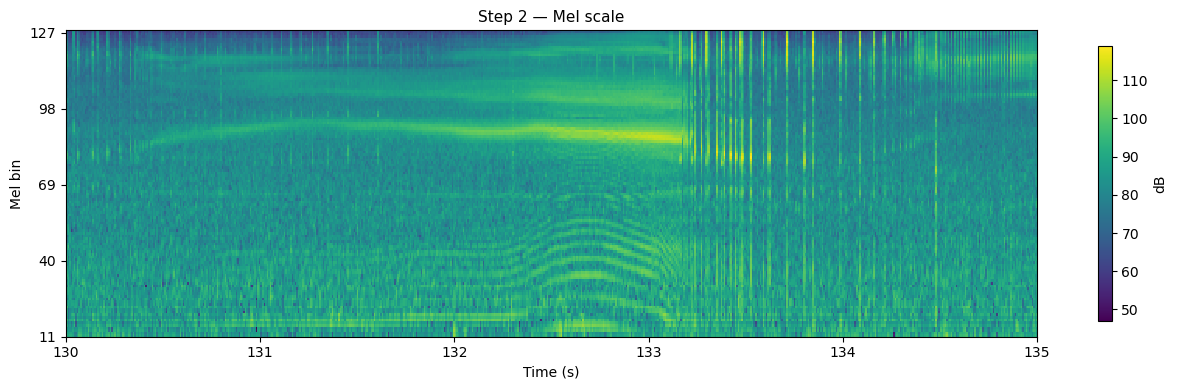

In [49]:
with torch.no_grad():
    mel_spec = pipeline.mel_scale(power_spec)   # (1, 128, T)

mel_db_np = pipeline.to_db(mel_spec / (1e-6 ** 2)).squeeze(0).numpy()

show_spec(mel_db_np[MEL_START:], "Step 2 — Mel scale",
          sr=SR, hop=HOP, cmap="viridis",
          mel_start=MEL_START, mel_end=MEL_END,
          start_sec=START_SEC, end_sec=END_SEC)

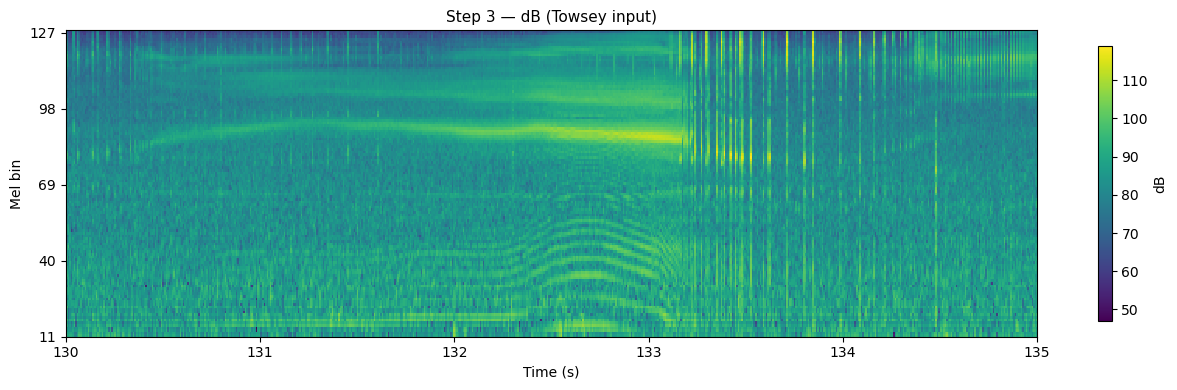

In [50]:
with torch.no_grad():
    db_spec = pipeline.to_db(mel_spec / (1e-6 ** 2))   # (1, 128, T)

S = db_spec.squeeze(0).numpy()[MEL_START:]   # input to Towsey

show_spec(S, "Step 3 — dB (Towsey input)",
          sr=SR, hop=HOP, cmap="viridis",
          mel_start=MEL_START, mel_end=MEL_END,
          start_sec=START_SEC, end_sec=END_SEC)

## Towsey A — modal noise per bin

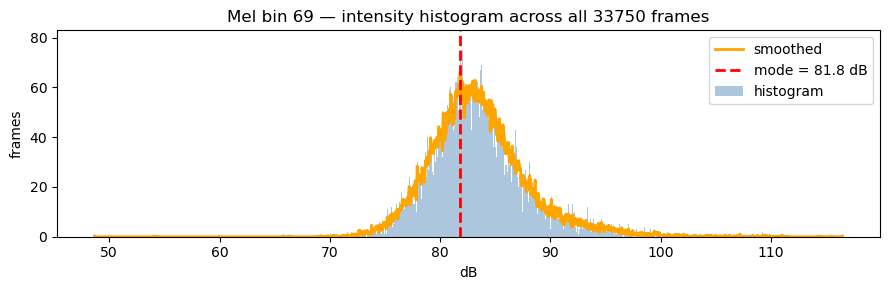

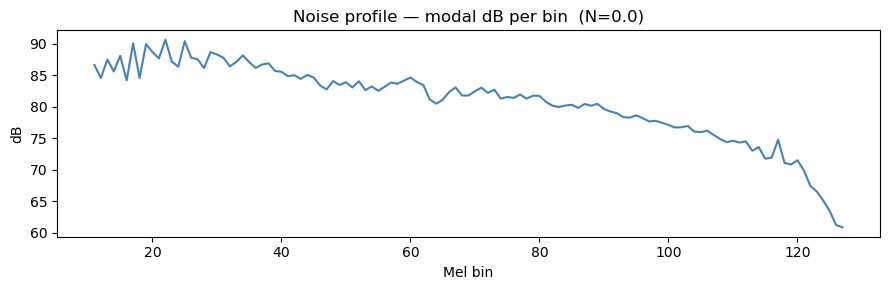

In [51]:
n_bins, n_frames = S.shape
N_HIST_BINS = max(10, n_frames // 8)
kernel      = np.ones(SMOOTH_WIN) / SMOOTH_WIN

# histogram for one example bin
example_bin = n_bins // 2
row = S[example_bin].astype(np.float64)
lo, hi = row.min(), row.max()
counts, edges = np.histogram(row, bins=N_HIST_BINS, range=(lo, hi))
counts_s   = np.convolve(counts.astype(float), kernel, mode="same")
modal_idx  = int(np.argmax(counts_s))
modal_val  = 0.5 * (edges[modal_idx] + edges[modal_idx + 1])

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(0.5*(edges[:-1]+edges[1:]), counts, width=(hi-lo)/N_HIST_BINS, alpha=0.45, color="steelblue", label="histogram")
ax.plot(0.5*(edges[:-1]+edges[1:]), counts_s, color="orange", linewidth=2, label="smoothed")
ax.axvline(modal_val, color="red", linestyle="--", linewidth=2, label=f"mode = {modal_val:.1f} dB")
ax.set_xlabel("dB")
ax.set_ylabel("frames")
ax.set_title(f"Mel bin {MEL_START + example_bin} — intensity histogram across all {n_frames} frames")
ax.legend()
plt.tight_layout()
plt.show()

# build full noise profile
noise_profile = np.zeros(n_bins, dtype=np.float64)
for i in range(n_bins):
    row = S[i].astype(np.float64)
    lo, hi = row.min(), row.max()
    if lo >= hi:
        noise_profile[i] = lo
        continue
    counts, edges = np.histogram(row, bins=N_HIST_BINS, range=(lo, hi))
    counts_s  = np.convolve(counts.astype(float), kernel, mode="same")
    modal_idx = min(int(np.argmax(counts_s)), int(0.95 * N_HIST_BINS))
    modal_val = 0.5 * (edges[modal_idx] + edges[modal_idx + 1])
    std_est   = 0.0
    if TOWSEY_N > 0 and modal_idx > 0:
        sub = counts_s[:modal_idx]
        total = sub.sum()
        if total > 0:
            cumsum  = np.cumsum(sub[::-1])
            idx     = min(int(np.searchsorted(cumsum, 0.68 * total)), modal_idx - 1)
            std_est = (idx + 1) * (hi - lo) / N_HIST_BINS
    noise_profile[i] = modal_val + TOWSEY_N * std_est

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(np.arange(MEL_START, MEL_START + n_bins), noise_profile, color="steelblue")
ax.set_xlabel("Mel bin")
ax.set_ylabel("dB")
ax.set_title(f"Noise profile — modal dB per bin  (N={TOWSEY_N})")
plt.tight_layout()
plt.show()

## Towsey B — subtract noise floor

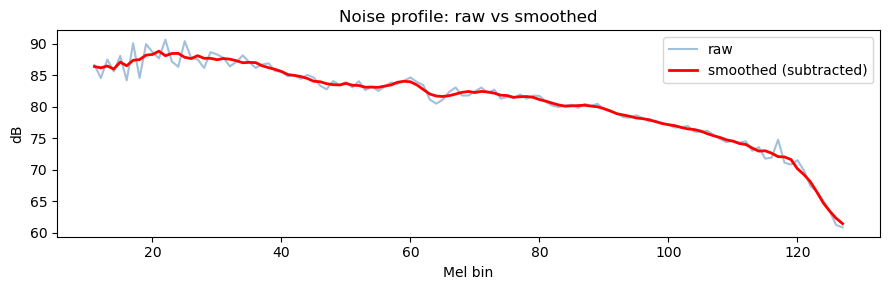

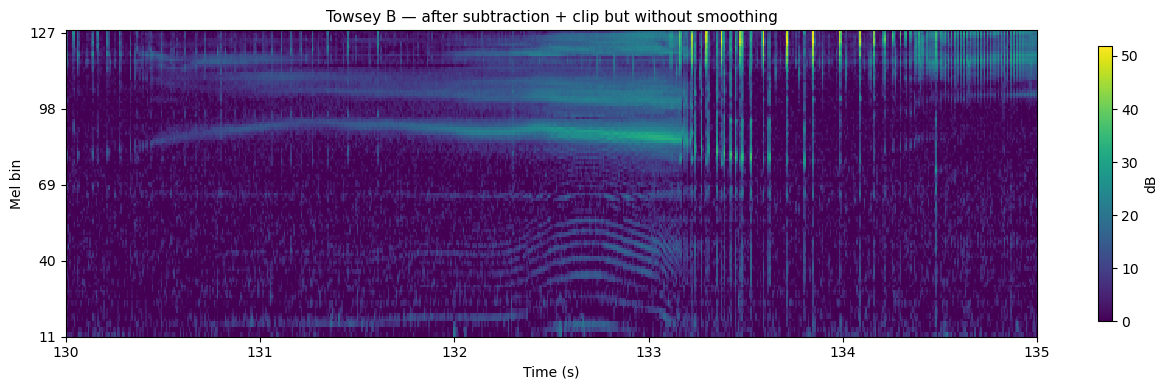

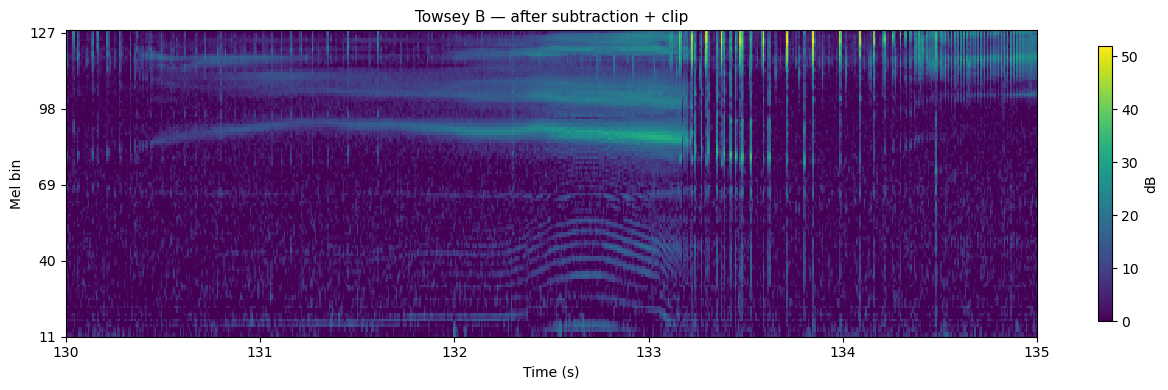

In [52]:
pad = len(kernel) // 2
noise_profile_smooth = np.convolve(np.pad(noise_profile, pad, mode='edge'), kernel, mode='valid')

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(np.arange(MEL_START, MEL_START + n_bins), noise_profile,        color="steelblue", alpha=0.5, label="raw")
ax.plot(np.arange(MEL_START, MEL_START + n_bins), noise_profile_smooth, color="red", linewidth=2, label="smoothed (subtracted)")
ax.set_xlabel("Mel bin")
ax.set_ylabel("dB")
ax.set_title("Noise profile: raw vs smoothed")
ax.legend()
plt.tight_layout()
plt.show()

S_denoised_without_smooth = np.maximum(S - noise_profile[:, np.newaxis], 0.0).astype(np.float32)
S_denoised = np.maximum(S - noise_profile_smooth[:, np.newaxis], 0.0).astype(np.float32)

show_spec(S_denoised_without_smooth, "Towsey B — after subtraction + clip but without smoothing",
          sr=SR, hop=HOP, cmap="viridis",
          mel_start=MEL_START, mel_end=MEL_END,
          start_sec=START_SEC, end_sec=END_SEC)

show_spec(S_denoised, "Towsey B — after subtraction + clip",
          sr=SR, hop=HOP, cmap="viridis",
          mel_start=MEL_START, mel_end=MEL_END,
          start_sec=START_SEC, end_sec=END_SEC)

## Towsey C — neighbourhood suppression

pixels zeroed: 72.0%


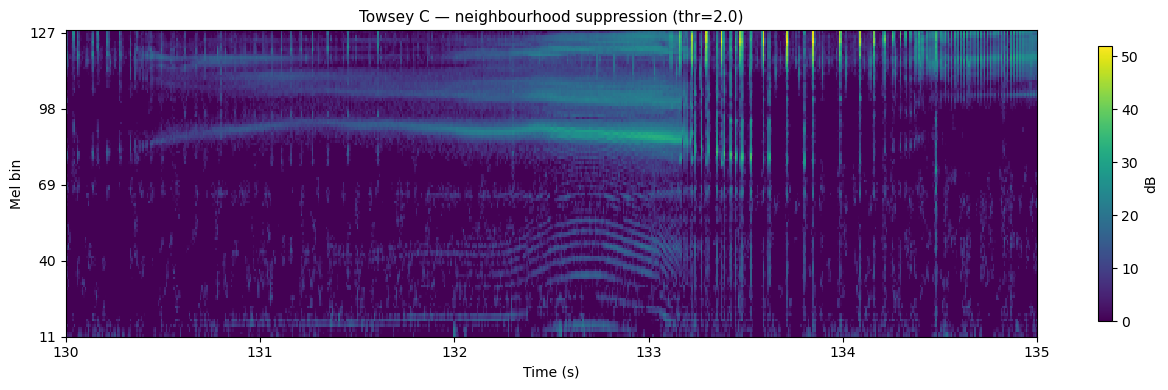

In [53]:
local_avg = uniform_filter(S_denoised, size=(9, 3), mode="reflect")
S_final   = np.where(local_avg < NEIGH_THR, 0.0, S_denoised).astype(np.float32)

print(f"pixels zeroed: {100*(S_final==0).mean():.1f}%")

show_spec(S_final, f"Towsey C — neighbourhood suppression (thr={NEIGH_THR})",
          sr=SR, hop=HOP, cmap="viridis",
          mel_start=MEL_START, mel_end=MEL_END,
          start_sec=START_SEC, end_sec=END_SEC)

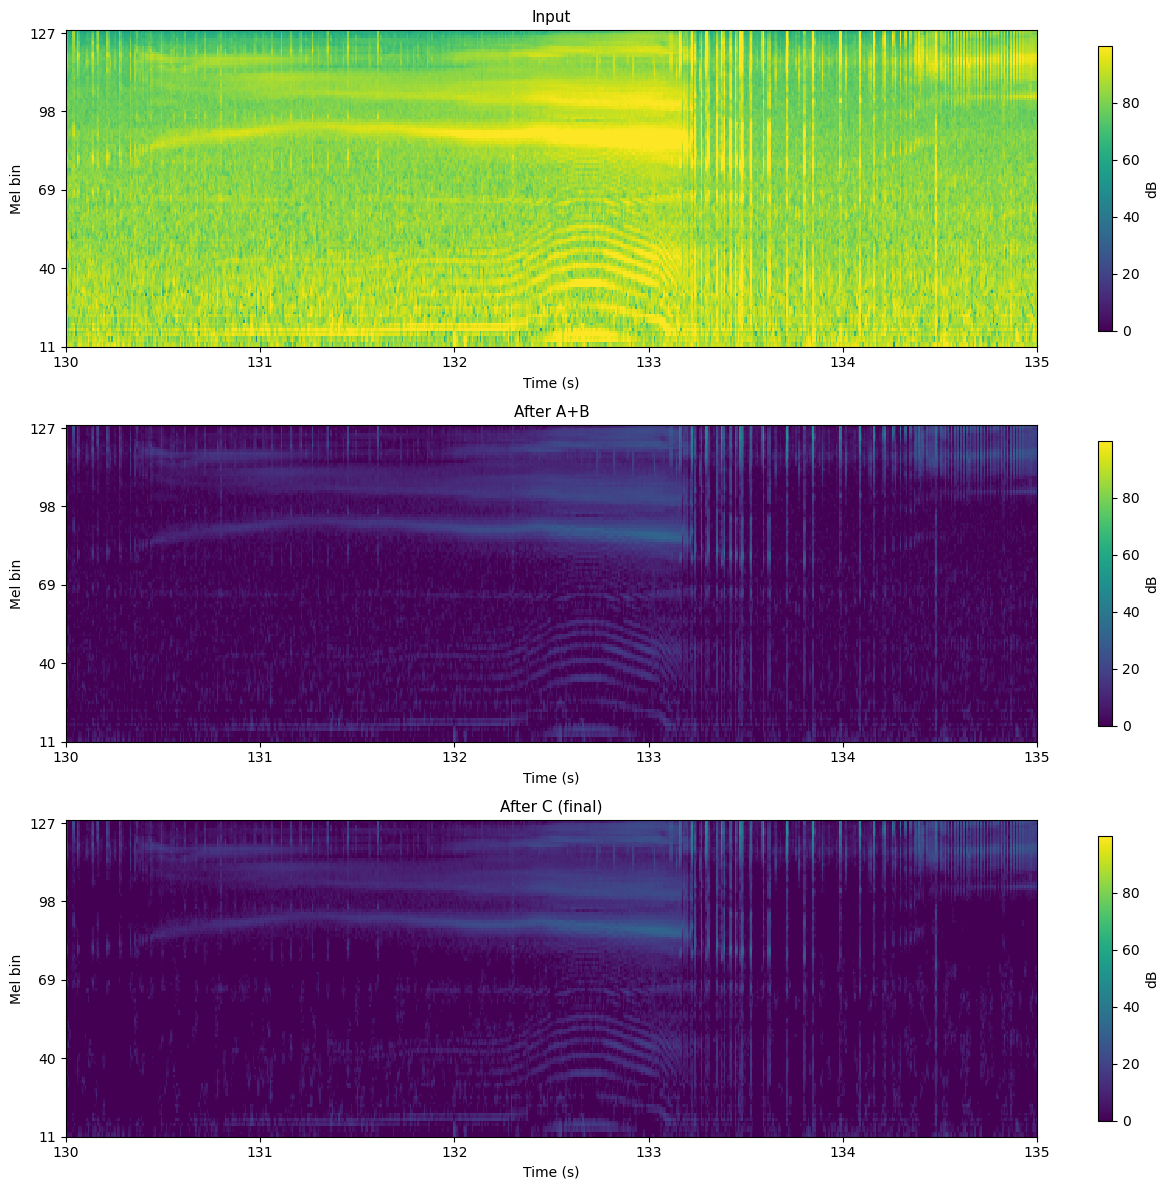

In [54]:
stages = [
    (S,          "Input"),
    (S_denoised, "After A+B"),
    (S_final,    "After C (final)"),
]
vmax = np.percentile(S, 99)

fig, axes = plt.subplots(len(stages), 1, figsize=(13, 4 * len(stages)))
for ax, (spec, title) in zip(axes, stages):
    show_spec(spec, title, sr=SR, hop=HOP, cmap="viridis",
              vmin=0, vmax=vmax, ax=ax,
              mel_start=MEL_START, mel_end=MEL_END,
              start_sec=START_SEC, end_sec=END_SEC)
plt.tight_layout()
plt.show()

## Effect of N

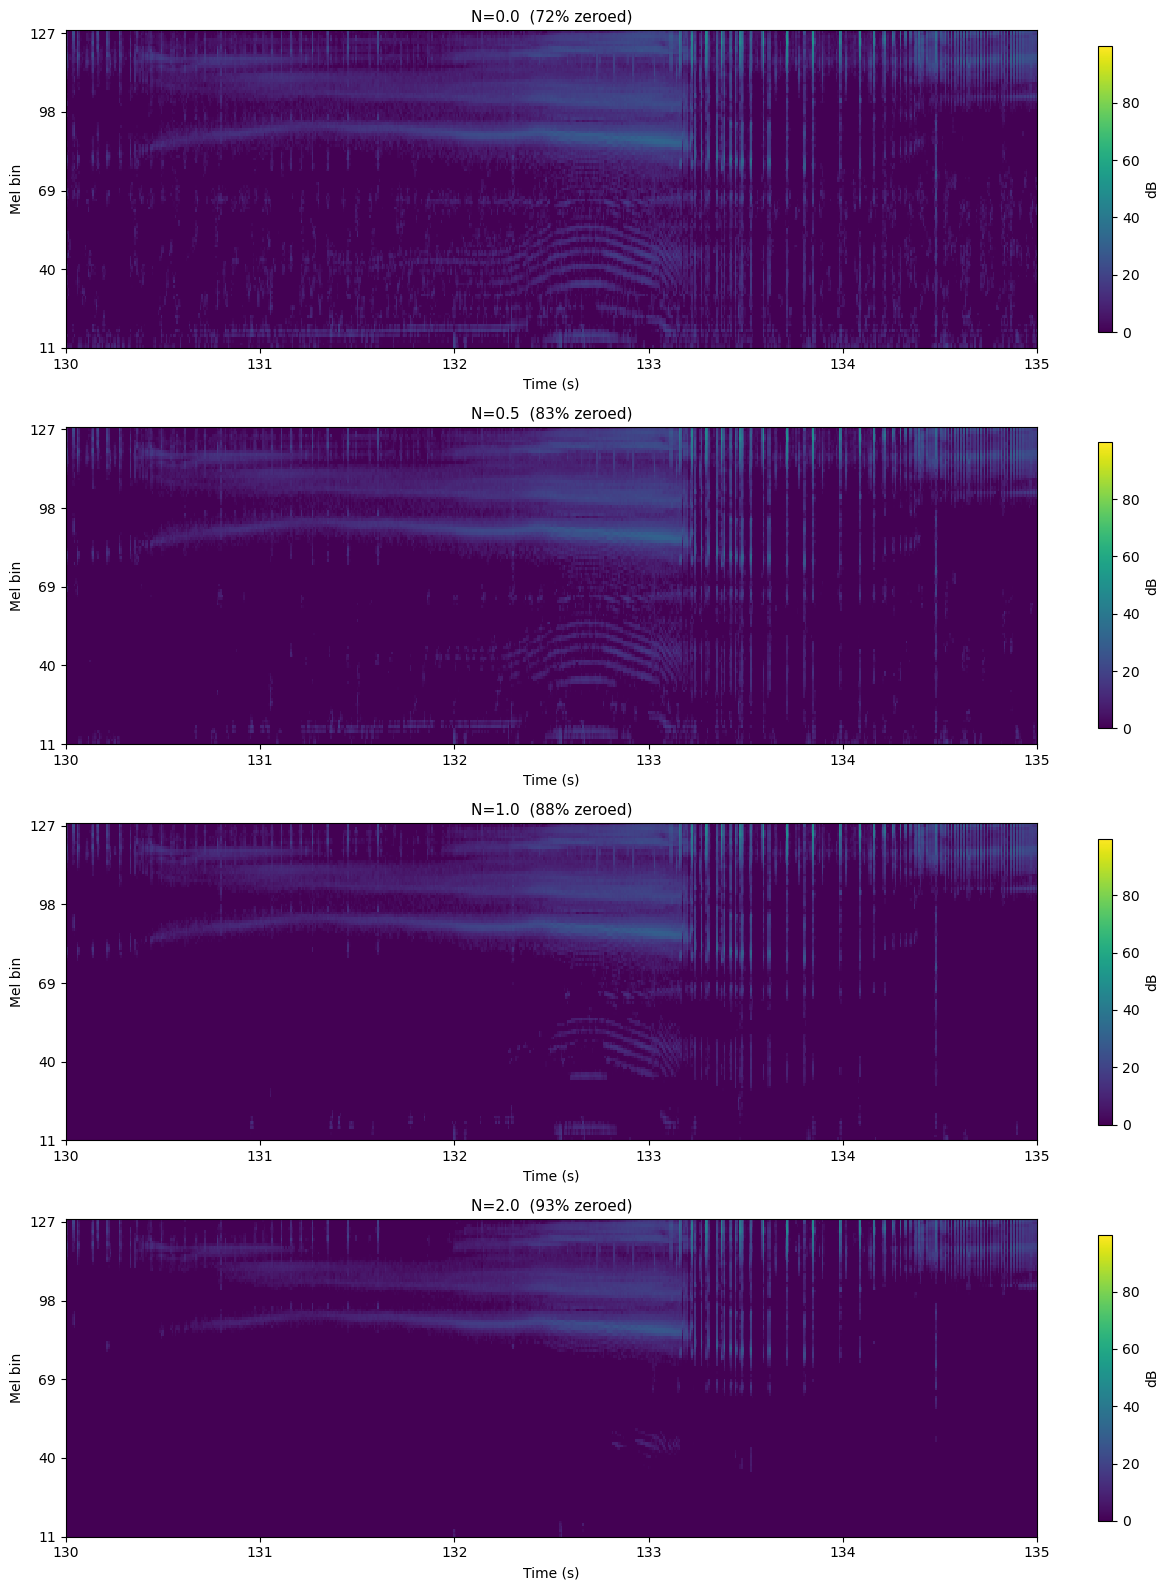

In [55]:
def towsey_full(S, N, smooth_window=5, neigh_thr=2.0):
    n_bins, n_frames = S.shape
    n_hist_bins = max(10, n_frames // 8)
    kernel  = np.ones(smooth_window) / smooth_window
    profile = np.zeros(n_bins, dtype=np.float64)
    for i in range(n_bins):
        row = S[i].astype(np.float64)
        lo, hi = row.min(), row.max()
        if lo >= hi:
            profile[i] = lo; continue
        counts, edges = np.histogram(row, bins=n_hist_bins, range=(lo, hi))
        counts_s  = np.convolve(counts.astype(float), kernel, mode="same")
        modal_idx = min(int(np.argmax(counts_s)), int(0.95 * n_hist_bins))
        modal_val = 0.5 * (edges[modal_idx] + edges[modal_idx + 1])
        std_est   = 0.0
        if N > 0 and modal_idx > 0:
            sub = counts_s[:modal_idx]; total = sub.sum()
            if total > 0:
                cumsum  = np.cumsum(sub[::-1])
                idx     = min(int(np.searchsorted(cumsum, 0.68 * total)), modal_idx - 1)
                std_est = (idx + 1) * (hi - lo) / n_hist_bins
        profile[i] = modal_val + N * std_est
    pad     = len(kernel) // 2
    profile = np.convolve(np.pad(profile, pad, mode='edge'), kernel, mode='valid')
    out = np.maximum(S - profile[:, np.newaxis], 0.0).astype(np.float32)
    if n_bins >= 9 and n_frames >= 3:
        avg = uniform_filter(out, size=(9, 3), mode="reflect")
        out = np.where(avg < neigh_thr, 0.0, out)
    return out

N_VALUES = [0.0, 0.5, 1.0, 2.0]
vmax = np.percentile(S, 99)

fig, axes = plt.subplots(len(N_VALUES), 1, figsize=(13, 4 * len(N_VALUES)))
for ax, n_val in zip(axes, N_VALUES):
    result = towsey_full(S, N=n_val, smooth_window=SMOOTH_WIN, neigh_thr=NEIGH_THR)
    zeroed = 100 * (result == 0).mean()
    show_spec(result, f"N={n_val}  ({zeroed:.0f}% zeroed)",
              sr=SR, hop=HOP, cmap="viridis", vmin=0, vmax=vmax, ax=ax,
              mel_start=MEL_START, mel_end=MEL_END,
              start_sec=START_SEC, end_sec=END_SEC)
plt.tight_layout()
plt.show()